In [9]:
from typing import Any, Literal, Optional, TypedDict  # Import typing tools for clear graph state shapes.

from langgraph.graph import END, START, StateGraph  # Import LangGraph building blocks for workflow routing.
from src.schemas.assessment import PHQ9AssessmentRequest
from src.services.assessment_service import score_phq9_assessment


In [3]:
HQ9_SCORE_OPTIONS: dict[int, str] = {  # Define the answer choices shown for every PHQ-9 question.
    0: "Not at all",  # Explain score 0 in user-friendly text.
    1: "Several days",  # Explain score 1 in user-friendly text.
    2: "More than half the days",  # Explain score 2 in user-friendly text.
    3: "Nearly every day",  # Explain score 3 in user-friendly text.
}  # Finish the answer-choice dictionary.


PHQ9_QUESTIONS: dict[int, str] = {  # Define the PHQ-9 question text by question number.
    1: "Little interest or pleasure in doing things",  # Store PHQ-9 question 1.
    2: "Feeling down, depressed, or hopeless",  # Store PHQ-9 question 2.
    3: "Trouble falling or staying asleep, or sleeping too much",  # Store PHQ-9 question 3.
    4: "Feeling tired or having little energy",  # Store PHQ-9 question 4.
    5: "Poor appetite or overeating",  # Store PHQ-9 question 5.
    6: "Feeling bad about yourself, or that you are a failure",  # Store PHQ-9 question 6.
    7: "Trouble concentrating on things",  # Store PHQ-9 question 7.
    8: "Moving or speaking slowly, or being unusually restless",  # Store PHQ-9 question 8.
    9: "Thoughts that you would be better off dead, or of hurting yourself",  # Store PHQ-9 question 9.
}  # Finish the question dictionary.


In [4]:
class PHQ9ConversationState(TypedDict, total=False):  # Define the shared memory shape for the LangGraph flow.
    answers: list[dict[str, int]]  # Store answers already collected from previous turns.
    incoming_score: Optional[int]  # Store the latest score sent by the user for this turn.
    notes: Optional[str]  # Store optional notes that should travel with the final assessment.
    current_question_id: int  # Store which question the frontend should show now.
    assistant_message: str  # Store the message/question the API returns to the frontend.
    score_options: dict[int, str]  # Store answer choices for the frontend.
    is_complete: bool  # Store whether all 9 answers have been collected.
    needs_answer: bool  # Store whether the frontend should wait for another score.
    result: Optional[dict[str, Any]]  # Store the final scored result when complete.
    crisis_support: Optional[dict[str, Any]]  # Store crisis resources when item 9 triggers risk.
    error: Optional[str]  # Store a safe validation message when the user sends bad input.

In [5]:
def _next_question_id(answers: list[dict[str, int]]) -> int:  # Create helper to find the next unanswered question.
    return len(answers) + 1  # The next question is one more than the number of saved answers.


def _build_question_message(question_id: int) -> str:  # Create helper to format a user-facing question.
    question = PHQ9_QUESTIONS[question_id]  # Look up the PHQ-9 question text.
    return f"Over the last 2 weeks, how often have you been bothered by: {question}?"  # Return conversational wording.

In [10]:
def record_answer(state: PHQ9ConversationState) -> PHQ9ConversationState:  # Define node that records the newest answer.
    answers = list(state.get("answers", []))  # Copy existing answers so we do not mutate input state directly.
    incoming_score = state.get("incoming_score")  # Read the score submitted on this turn.

    if incoming_score is None:  # Check if this is the first call that only starts the conversation.
        return {"answers": answers, "error": None}  # Return unchanged answers and no error.

    if incoming_score not in PHQ9_SCORE_OPTIONS:  # Validate that the score is 0, 1, 2, or 3.
        return {"answers": answers, "error": "Please answer with 0, 1, 2, or 3."}  # Return a safe validation error.

    if len(answers) >= 9:  # Check if the assessment is already complete.
        return {"answers": answers, "error": "This PHQ-9 assessment is already complete."}  # Return a safe completion error.

    question_id = _next_question_id(answers)  # Calculate which question this score belongs to.
    answers.append({"question_id": question_id, "score": incoming_score})  # Save the answer in your existing schema shape.
    return {"answers": answers, "error": None}  # Return the updated answers to LangGraph.


def route_after_answer(state: PHQ9ConversationState) -> Literal["ask_question", "score_assessment"]:  # Decide the next graph node.
    answers = state.get("answers", [])  # Read collected answers from state.
    if len(answers) >= 9 and not state.get("error"):  # Check if all answers are present and valid.
        return "score_assessment"  # Route to scoring when the screener is complete.
    return "ask_question"  # Route to asking the next question otherwise.


def ask_question(state: PHQ9ConversationState) -> PHQ9ConversationState:  # Define node that prepares the next question.
    answers = state.get("answers", [])  # Read answers collected so far.
    question_id = min(_next_question_id(answers), 9)  # Pick the next question while staying inside 1 through 9.
    message = state.get("error") or _build_question_message(question_id)  # Show an error first, otherwise show the question.

    return {  # Return the frontend-friendly question payload.
        "current_question_id": question_id,  # Tell the frontend which question is active.
        "assistant_message": message,  # Send the question or validation message.
        "score_options": PHQ9_SCORE_OPTIONS,  # Send answer labels for buttons/radio choices.
        "is_complete": False,  # Tell the frontend the assessment is not done yet.
        "needs_answer": True,  # Tell the frontend to collect one more score.
        "result": None,  # Keep final result empty until all 9 answers exist.
        "crisis_support": None,  # Keep crisis support empty until scoring detects risk.
    }  # Finish the question payload.

async def score_assessment(state: PHQ9ConversationState) -> PHQ9ConversationState:  # Define async node that scores the completed PHQ-9.
    request = PHQ9AssessmentRequest(  # Build your existing complete PHQ-9 request model.
        answers=state.get("answers", []),  # Pass all collected answers into the existing schema.
        notes=state.get("notes"),  # Pass optional notes into the existing schema.
    )  # Finish request construction.

    result = await score_phq9_assessment(request)  # Reuse your existing scoring logic.
    result_data = result.model_dump()  # Convert the Pydantic result into a JSON-safe dictionary.

    return {  # Return the completed assessment payload.
        "assistant_message": "PHQ-9 assessment complete.",  # Tell the frontend the flow is finished.
        "score_options": PHQ9_SCORE_OPTIONS,  # Keep options available for stable response shape.
        "is_complete": True,  # Tell the frontend the assessment is done.
        "needs_answer": False,  # Tell the frontend no more PHQ-9 answers are needed.
        "result": result_data,  # Return the scored PHQ-9 result.
        "crisis_support": result_data.get("crisis_support"),  # Surface crisis support when item 9 is positive.
        "error": None,  # Clear any previous validation error.
    }


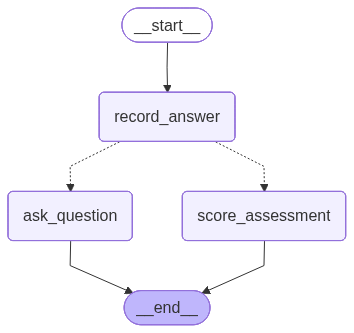

In [12]:
def build_phq9_conversation_graph():  # Create a function that builds the graph once.
    builder = StateGraph(PHQ9ConversationState)  # Create a LangGraph state machine using our state shape.
    builder.add_node("record_answer", record_answer)  # Add the node that stores the latest user answer.
    builder.add_node("ask_question", ask_question)  # Add the node that returns the next PHQ-9 question.
    builder.add_node("score_assessment", score_assessment)  # Add the node that scores the completed PHQ-9.
    builder.add_edge(START, "record_answer")  # Tell LangGraph to start by recording any submitted answer.
    builder.add_conditional_edges("record_answer", route_after_answer)  # Route either to next question or scoring.
    builder.add_edge("ask_question", END)  # Stop after asking one question so the frontend can answer.
    builder.add_edge("score_assessment", END)  # Stop after scoring so the frontend can show the result.
    return builder.compile()  # Compile the graph before using it.


phq9_conversation_graph = build_phq9_conversation_graph()  # Build one reusable graph instance for the app.

phq9_conversation_graph